# Analisis Volumen y Calidad de Pagos

# Proposito del Notebook

- Responder preguntas relevantes del negocio, centrándose en el volumen, características y calidad de los pagos.
- Graficar tendencias, distribuciones y comportamiento de los datos.

# Conexiones y librerias

In [1]:
from conexiones import obtener_engine
import pandas as pd 
import matplotlib.pyplot as plt
from sqlalchemy import text
import seaborn as sns 
engine = obtener_engine()

df_pagos = pd.read_sql_query(
    text("""
        SELECT 
            cliente_llave,
            producto_llave,
            sucursal_llave,
            oficial_llave,
            fecha_pago,
            dias_retraso,
            canal_pago,
            monto_pagado_total,
            monto_capital_pagado,
            monto_interes_pagado,
            monto_mora_pagado,
            estado_pago
        FROM oro.fact_pagos"""),
    con= engine
)
df_pagos_tra = df_pagos.copy()

df_sucursales = pd.read_sql_query(
    text("""
        SELECT 
            sucursal_llave,
            nombre_sucursal
        FROM oro.dim_sucursales"""),
    con= engine
)
df_sucursales_tra = df_sucursales.copy()

df_oficiales = pd.read_sql_query(
    text("""
        SELECT 
            oficial_llave,
            nombres,
            apellido_paterno,
            apellido_materno 
        FROM oro.dim_oficiales_credito"""),
    con= engine
)
df_oficiales_tra = df_oficiales.copy()

df_productos = pd.read_sql_query(
    text("""
        SELECT 
            producto_llave,
            nombre_producto
        FROM oro.dim_productos_crediticios"""),
    con= engine
)
df_productos_tra = df_productos.copy()

In [2]:
df_pagos_tra["fecha_pago"] = pd.to_datetime(df_pagos_tra.fecha_pago)

In [3]:
df_productos_tra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   producto_llave   8 non-null      int64 
 1   nombre_producto  8 non-null      object
dtypes: int64(1), object(1)
memory usage: 256.0+ bytes


In [4]:
# Para estandarizar todo a PEN, lo que voy a realizar es cambiar los creditos hipotecarios a soles 
tasa_cambio = 3.36
mascara_creditos_usd = df_pagos_tra.producto_llave == 7

df_pagos_tra.loc[mascara_creditos_usd,"monto_pagado_total"] = round(df_pagos_tra.loc[mascara_creditos_usd,"monto_pagado_total"]*tasa_cambio,2)
df_pagos_tra.loc[mascara_creditos_usd,"monto_capital_pagado"] = round(df_pagos_tra.loc[mascara_creditos_usd,"monto_capital_pagado"]*tasa_cambio,2)
df_pagos_tra.loc[mascara_creditos_usd,"monto_interes_pagado"] = round(df_pagos_tra.loc[mascara_creditos_usd,"monto_interes_pagado"]*tasa_cambio,2)
df_pagos_tra.loc[mascara_creditos_usd,"monto_mora_pagado"] = round(df_pagos_tra.loc[mascara_creditos_usd,"monto_mora_pagado"]*tasa_cambio,2)

In [5]:
sns.set_theme(style='whitegrid')

# Volumen de pagos

## ¿Cuál es la tendencia anual de los pagos?

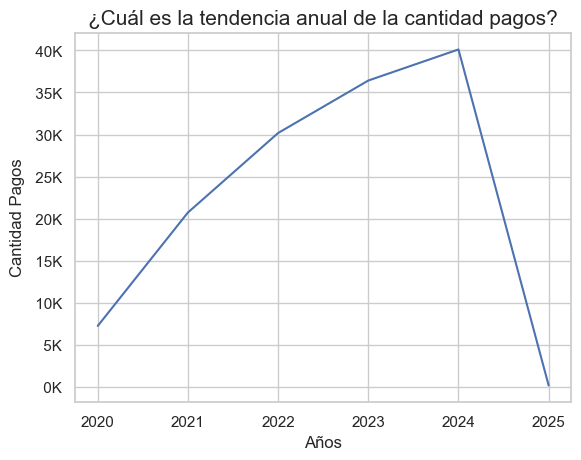

In [6]:
df_tendencia_pagos = (
    df_pagos_tra.fecha_pago.dt.year
    .reset_index()
    .value_counts('fecha_pago')
    .reset_index()
    .sort_values(by='fecha_pago')
)

sns.lineplot(
    data=df_tendencia_pagos,
    x='fecha_pago',
    y='count'
)
plt.title("¿Cuál es la tendencia anual de la cantidad pagos?",fontsize=15)
plt.ylabel("Cantidad Pagos")
plt.xlabel("Años")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f" {round(y/1000)}K"))
plt.show()

## ¿Cuál es la tendencia anual del dinero generado por el pago de intereses?

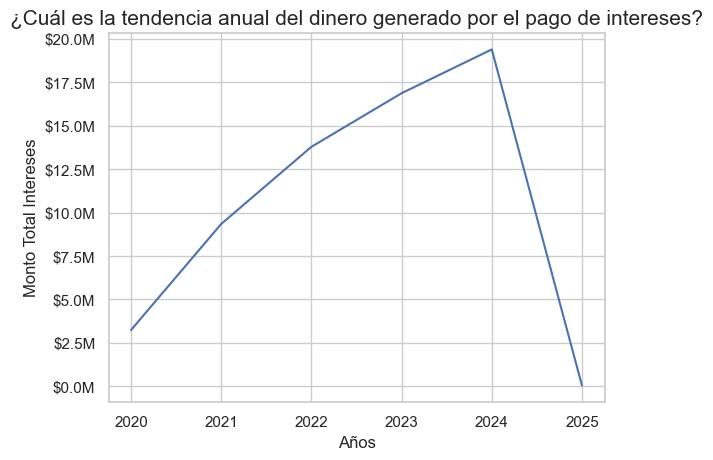

In [7]:
df_tendencia_intereses = df_pagos_tra[["fecha_pago","monto_interes_pagado"]].copy()
df_tendencia_intereses["anio"] = df_tendencia_intereses.fecha_pago.dt.year
df_tendencia_intereses = (
    df_tendencia_intereses
    .groupby("anio")["monto_interes_pagado"]
    .sum()
    .reset_index()
    .sort_values(by='anio')
)
sns.lineplot(
    data=df_tendencia_intereses,
    x='anio',
    y='monto_interes_pagado'
)
plt.title("¿Cuál es la tendencia anual del dinero generado por el pago de intereses?",fontsize=15)
plt.ylabel("Monto Total Intereses")
plt.xlabel("Años")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${round(y/1000000,1)}M"))
plt.show()

## ¿Cuál es la tendencia anual del dinero generado por el pago de mora?

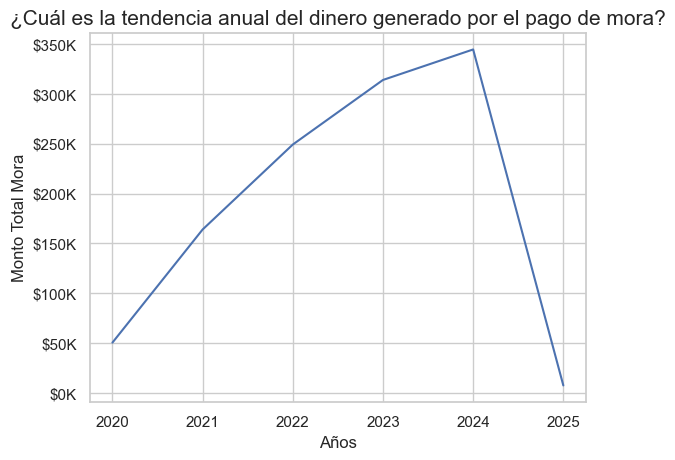

In [8]:
df_tendencia_intereses = df_pagos_tra[["fecha_pago","monto_mora_pagado"]].copy()
df_tendencia_intereses["anio"] = df_tendencia_intereses.fecha_pago.dt.year
df_tendencia_intereses = (
    df_tendencia_intereses
    .groupby("anio")["monto_mora_pagado"]
    .sum()
    .reset_index()
    .sort_values(by='anio')
)
sns.lineplot(
    data=df_tendencia_intereses,
    x='anio',
    y='monto_mora_pagado'
)
plt.title("¿Cuál es la tendencia anual del dinero generado por el pago de mora?",fontsize=15)
plt.ylabel("Monto Total Mora")
plt.xlabel("Años")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${round(y/1000)}K"))
plt.show()

## ¿Cuál es la tendencia anual del pago de capital?

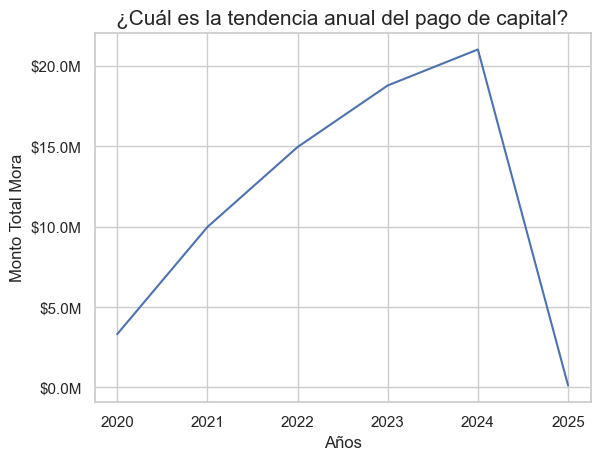

In [9]:
df_tendencia_capital = df_pagos_tra[["fecha_pago","monto_capital_pagado"]].copy()
df_tendencia_capital["anio"] = df_tendencia_capital.fecha_pago.dt.year
df_tendencia_capital = (
    df_tendencia_capital
    .groupby("anio")["monto_capital_pagado"]
    .sum()
    .reset_index()
    .sort_values(by='anio')
)
sns.lineplot(
    data=df_tendencia_capital,
    x='anio',
    y='monto_capital_pagado'
)
plt.title("¿Cuál es la tendencia anual del pago de capital?",fontsize=15)
plt.ylabel("Monto Total Mora")
plt.xlabel("Años")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${round(y/1000000,1)}M"))
plt.show()

## ¿Qué sucursales tienen mayor cantidad de pagos?

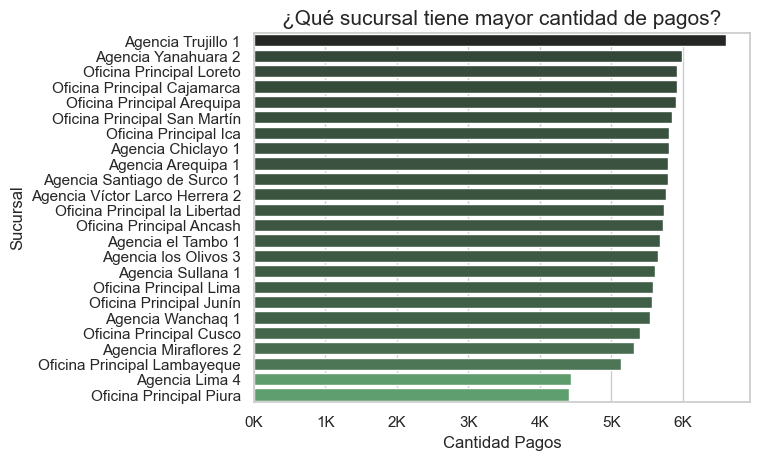

In [10]:
df_pagos_sucursal = df_pagos_tra["sucursal_llave"].reset_index().merge(
    right=df_sucursales_tra,
    on='sucursal_llave'
)

df_pagos_sucursal = (
    df_pagos_sucursal.nombre_sucursal
    .value_counts()
    .reset_index()
    .sort_values(by='count',ascending=False)
)
sns.barplot(
    data=df_pagos_sucursal,
    x='count',
    y='nombre_sucursal',
    hue='count',
    palette='dark:g_r',
    legend=False
)

plt.title("¿Qué sucursal tiene mayor cantidad de pagos?",fontsize=15)
plt.ylabel("Sucursal")
plt.xlabel("Cantidad Pagos")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{round(x/1000)}K"))
plt.show()

## ¿Qué sucursales han generado mayor cantidad de ingresos?

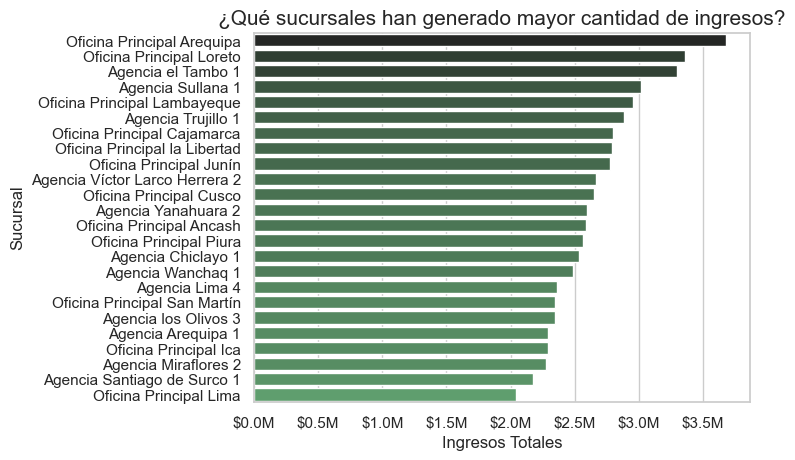

In [11]:
df_ingresos_sucursales = df_pagos_tra[["sucursal_llave","monto_interes_pagado","monto_mora_pagado"]].merge(
    right=df_sucursales_tra,
    on='sucursal_llave'
)

df_ingresos_sucursales["ingresos"] = df_ingresos_sucursales.monto_interes_pagado + df_ingresos_sucursales.monto_mora_pagado
df_ingresos_sucursales = (
    df_ingresos_sucursales.groupby("nombre_sucursal")
    .agg(
        ingresos_totales = ('ingresos','sum')
    )
    .reset_index()
    .sort_values(by='ingresos_totales',ascending=False)
)
sns.barplot(
    data=df_ingresos_sucursales,
    x='ingresos_totales',
    y='nombre_sucursal',
    hue='ingresos_totales',
    palette='dark:g_r',
    legend=False
)

plt.title("¿Qué sucursales han generado mayor cantidad de ingresos?",fontsize=15)
plt.ylabel("Sucursal")
plt.xlabel("Ingresos Totales")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${round(x/1000000,1)}M"))
plt.show()

## ¿Qué productos crediticios generaron mayor cantidad de ingresos?

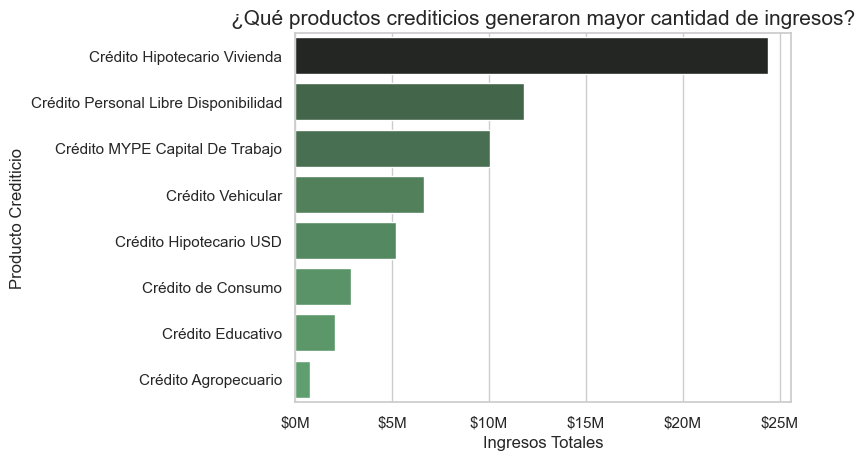

In [12]:
df_ingresos_sucursales = df_pagos_tra[["producto_llave","monto_interes_pagado","monto_mora_pagado"]].merge(
    right= df_productos_tra,
    on='producto_llave'
)

df_ingresos_sucursales["ingresos"] = df_ingresos_sucursales.monto_interes_pagado + df_ingresos_sucursales.monto_mora_pagado
df_ingresos_sucursales = (
    df_ingresos_sucursales.groupby("nombre_producto")
    .agg(
        ingresos_totales = ('ingresos','sum')
    )
    .reset_index()
    .sort_values(by='ingresos_totales',ascending=False)
)
sns.barplot(
    data=df_ingresos_sucursales,
    x='ingresos_totales',
    y='nombre_producto',
    hue='ingresos_totales',
    palette='dark:g_r',
    legend=False
)

plt.title("¿Qué productos crediticios generaron mayor cantidad de ingresos?",fontsize=15)
plt.ylabel("Producto Crediticio")
plt.xlabel("Ingresos Totales")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${round(x/1000000)}M"))
plt.show()

## ¿Qué canales de pago tienen mayor cantidad de pagos y mueven mayor cantidad de dinero?

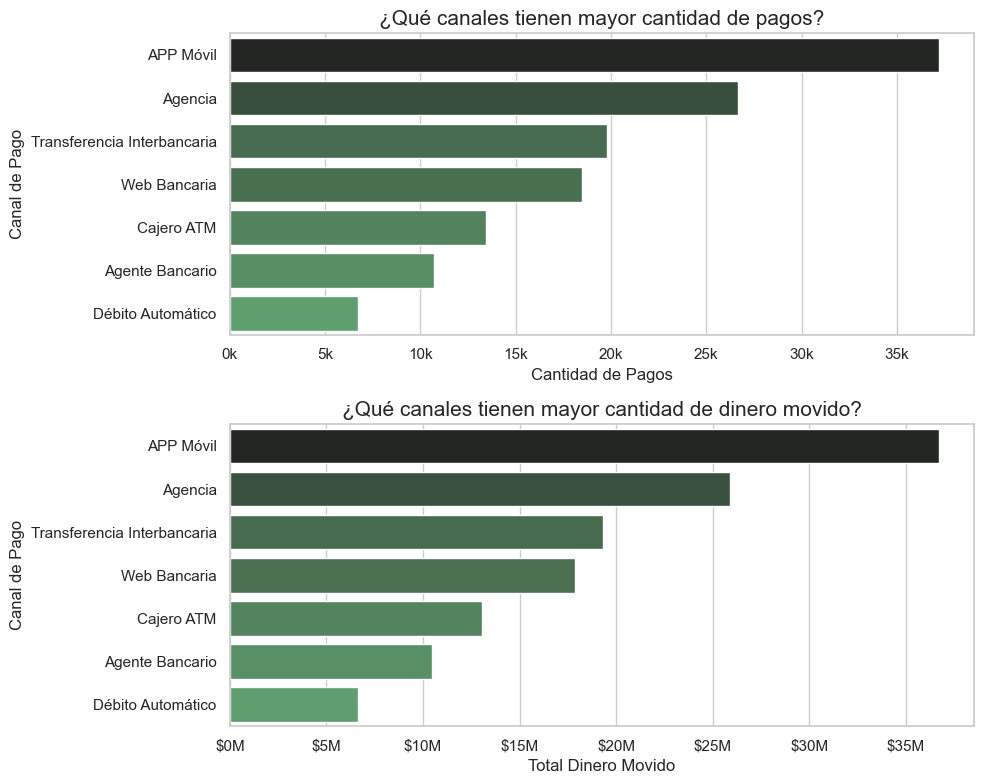

In [13]:
df_canti_pagos_dinero = df_pagos_tra[["canal_pago","monto_pagado_total"]][df_pagos_tra.canal_pago != 'n/a'].copy()

fig, ax = plt.subplots(2,1,figsize=(10,8))
# Cantidad pagos por canal de pago 
df_canti_pag_canal = df_canti_pagos_dinero.canal_pago.value_counts().reset_index().sort_values(by='count',ascending=False)
sns.barplot(
    data=df_canti_pag_canal,
    x='count',
    y='canal_pago',
    hue='count',
    legend=False,
    palette='dark:g_r',
    ax=ax[0]
)
ax[0].set_title("¿Qué canales tienen mayor cantidad de pagos?",fontsize=15)
ax[0].set_xlabel("Cantidad de Pagos")
ax[0].set_ylabel("Canal de Pago")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f"{round(x/1000)}k"))
# Cantidad de dinero movido por canal de pago
df_total_dinero_canal = (
    df_canti_pagos_dinero.groupby("canal_pago")
    .agg(
        total_dinero_movido = ("monto_pagado_total","sum")
    ).reset_index()
    .sort_values(by='total_dinero_movido',ascending = False)
)
sns.barplot(
    data=df_total_dinero_canal,
    x='total_dinero_movido',
    y='canal_pago',
    hue='total_dinero_movido',
    legend=False,
    palette='dark:g_r',
    ax=ax[1]
)
ax[1].set_title("¿Qué canales tienen mayor cantidad de dinero movido?",fontsize=15)
ax[1].set_xlabel("Total Dinero Movido")
ax[1].set_ylabel("Canal de Pago")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f"${round(x/1000000)}M"))
fig.tight_layout()
plt.show()

# Calidad de los pagos

## ¿Qué estados de pago son los más populares?

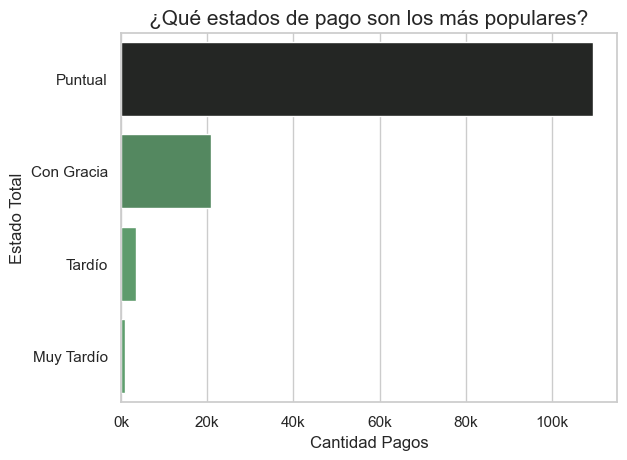

In [14]:
df_estados_pago = (
    df_pagos_tra.estado_pago.copy()
    .reset_index()
    .estado_pago
    .value_counts()
    .reset_index()
    .sort_values(by='count',ascending=False)
)
sns.barplot(
    data=df_estados_pago,
    y='estado_pago',
    x='count',
    hue='count',
    legend=False,
    palette= 'dark:g_r'
)
plt.title("¿Qué estados de pago son los más populares?",fontsize=15)
plt.ylabel("Estado Total")
plt.xlabel("Cantidad Pagos")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f"{round(x/1000)}k"))
plt.show()

## ¿Cuáles son los rangos más populares de días de retraso de los pagos?

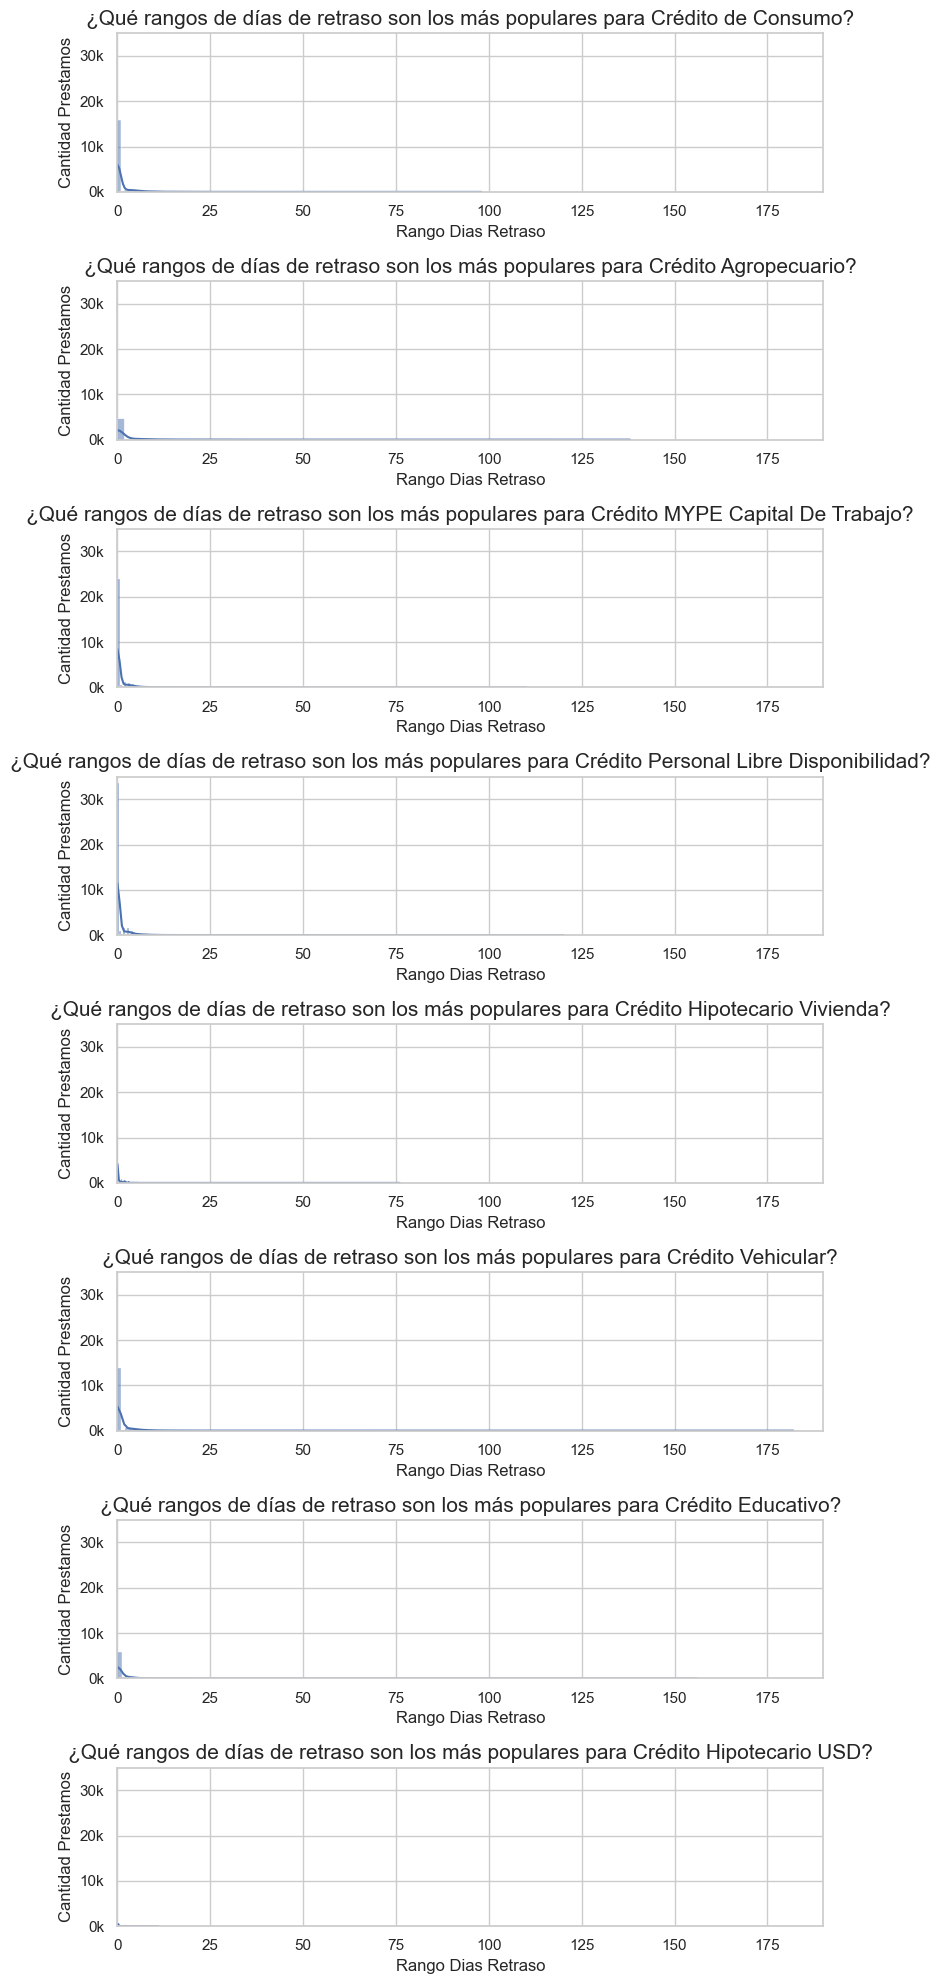

In [15]:
df_rango_mora_product = df_pagos_tra[["producto_llave","dias_retraso"]].merge(
    right= df_productos_tra,
    on='producto_llave'
)

nombre_productos = list(df_rango_mora_product.nombre_producto.unique())
cantidad_productos = len(nombre_productos)
fig, ax = plt.subplots(nrows=cantidad_productos, ncols= 1, figsize=(8,20))

for i in range(cantidad_productos):
    df_grafico_rango_dias_retraso = df_rango_mora_product.dias_retraso[df_rango_mora_product.nombre_producto == nombre_productos[i]]
    
    sns.histplot(
        data= df_grafico_rango_dias_retraso,
        bins = 'scott',
        ax=ax[i],
        kde = True
    )
    ax[i].set_title(f"¿Qué rangos de días de retraso son los más populares para {nombre_productos[i]}?", fontsize=15)
    ax[i].set_xlabel("Rango Dias Retraso")
    ax[i].set_ylabel("Cantidad Prestamos")
    ax[i].set_xlim(0,190)
    ax[i].set_ylim(0,35000)
    ax[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{round(x/1000)}k"))

fig.tight_layout()